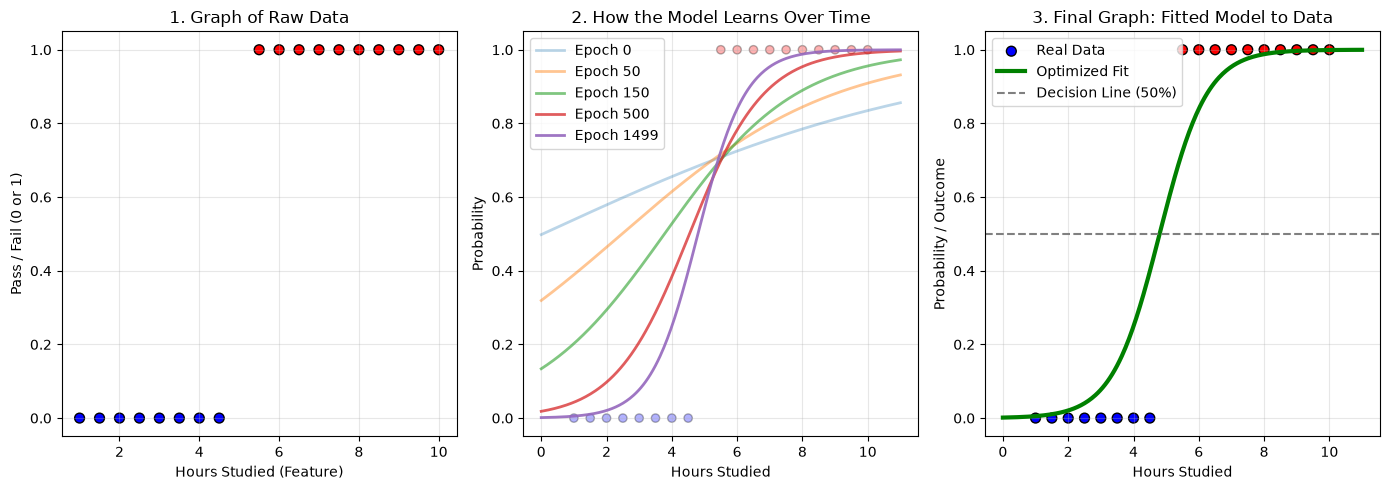

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


df = pd.read_csv("C:\\Users\\jacka\\OneDrive\\Desktop\\M.tech\\mll\\logistic_regression\\simple_study_data.csv")
X = df['Hours_Studied'].values
y = df['Passed_Exam'].values

# UNDERSTANDING HOW THE MODEL LEARNS (Gradient Descent from Scratch)

# The Sigmoid Function converts numbers into probability scores (0 to 1)
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Initialize model parameters randomly
slope = 0.1
intercept = 0.0
learning_rate = 0.1
epochs = 1500  # Number of learning iterations

# We record snapshots at specific intervals to show how the line learns
history = []
snapshots = [0, 50, 150, 500, 1499]

for epoch in range(epochs):
    # Calculating current predictions: z = (slope * X) + intercept
    z = slope * X + intercept
    predictions = sigmoid(z)
    
    # Calculating the error metrics (Gradients)
    errors = predictions - y
    slope_gradient = np.mean(errors * X)
    intercept_gradient = np.mean(errors)
    
    
    slope -= learning_rate * slope_gradient
    intercept -= learning_rate * intercept_gradient
    
    # Saving snapshots of the curve shape at key stages
    if epoch in snapshots:
        history.append((epoch, slope.copy(), intercept.copy()))

# PLOTTING THE STAGES OF LEARNING
plt.figure(figsize=(14, 5))
X_line = np.linspace(0, 11, 300)

# GRAPH 1: The Raw Data 
plt.subplot(1, 3, 1)
plt.scatter(X, y, c=y, cmap='bwr', edgecolor='k', s=50)
plt.title("1. Graph of Raw Data")
plt.xlabel("Hours Studied (Feature)")
plt.ylabel("Pass / Fail (0 or 1)")
plt.grid(True, alpha=0.3)

# GRAPH 2: The Learning Phases 
plt.subplot(1, 3, 2)
plt.scatter(X, y, c=y, cmap='bwr', edgecolor='k', alpha=0.3)
for idx, (epoch, s, i) in enumerate(history):
    y_curve = sigmoid(s * X_line + i)
    # Give later steps a darker color to show advancement
    alpha_val = 0.3 + (idx * 0.15)
    plt.plot(X_line, y_curve, label=f'Epoch {epoch}', alpha=alpha_val, linewidth=2)
plt.title("2. How the Model Learns Over Time")
plt.xlabel("Hours Studied")
plt.ylabel("Probability")
plt.legend()
plt.grid(True, alpha=0.3)

# GRAPH 3: Final Data with Model Fit 
plt.subplot(1, 3, 3)
plt.scatter(X, y, c=y, cmap='bwr', edgecolor='k', s=50, label='Real Data')
final_y_curve = sigmoid(slope * X_line + intercept)
plt.plot(X_line, final_y_curve, color='green', linewidth=3, label='Optimized Fit')
plt.axhline(0.5, color='gray', linestyle='--', label='Decision Line (50%)')
plt.title("3. Final Graph: Fitted Model to Data")
plt.xlabel("Hours Studied")
plt.ylabel("Probability / Outcome")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
